# 가격·기후·거시경제로 단일 모델 비교

DLinear · NLinear · XGBoost · LightGBM · PatchTST · TimesNet을 **5·20·60거래일 누적 로그수익률** 예측으로 비교한다. 모든 후보가 같은 가격·기후·거시 피처와 60거래일 창을 받는다. Persistence(가격 유지)를 기준선으로 둔다. **앙상블은 하지 않는다.** 이후 단순평균 실험에 사용할 수 있도록 개별 예측만 저장한다.

- 입력: 기존 `data/processed/2014-07-01_2025-12-31/`의 원천별 Parquet. 네트워크 수집·서비스 변경 없음.
- 학습 시작 2015년, 2014년은 입력 계산 버퍼. 검증은 2022년/2023년 expanding folds, 설정 고정 후 2024~2025년 재평가.
- **2024~2025년은 이전 실험에서 이미 본 구간이다. 미사용 Test나 live 성과가 아니다.** 검증 구간도 기존 연구에서 사용했으며 새로운 독립 검증이라고 주장하지 않는다.
- 한 seed와 제한된 설정으로 수행하는 초기 비교다. 튜닝 횟수를 맞춰도 계산량·최적화 난도가 같지는 않으며 모델의 최대 성능을 증명하지 않는다.
- 신경망은 모두 scalar-return 회귀 변형이다. PatchTST/TimesNet 원 논문의 벤치마크 재현과 구분한다.

아래 표와 그래프는 실행된 계산에서 생성된다. 기존 노트북·학습 artifact를 덮어쓰지 않는다.

### 이번 실행 결과 · seed 42

| 지평 | 검증 선택 | 선택 후보 재평가 RMSE | 사후 단일 모델 최저 | 최저 RMSE |
|---|---|---:|---|---:|
| 5거래일 | Persistence | 0.05444 | DLinear | 0.05574 |
| 20거래일 | Persistence | 0.11300 | LightGBM | 0.11251 |
| 60거래일 | DLinear | 0.16388 | PatchTST | 0.16050 |

5일은 모든 단일 모델이 Persistence보다 나빴다. 20일 사후 최저 LightGBM의 개선은 약 0.44%다. 60일 검증 선택 DLinear는 과거 재평가에서 Persistence보다 RMSE가 약 11.78% 낮았고, 사후 최저 PatchTST는 약 13.60% 낮았다. **사후 최저값으로 선택을 바꾸지 않으며 안정적 우월성을 확정하지 않는다.**


## 1. 실행 환경과 고정 설정

Mac에서는 기존 외부 Python 3.12 `~/.virtualenvs/coffee-price-prediction/bin/python`을 커널로 선택한다. 필요한 패키지는 저장소 `requirements.txt`에 있다. 이 노트북은 패키지를 설치하거나 업그레이드하지 않는다. CPU·단일 thread를 사용하며 설정을 바꾸면 전체를 처음부터 다시 실행한다.

In [1]:
import os
import sys
import platform
import tempfile
import time
import hashlib
from pathlib import Path
from datetime import datetime, timezone
from importlib.metadata import version

for key in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "VECLIB_MAXIMUM_THREADS"):
    os.environ[key] = "1"
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "coffee-matplotlib"))
os.environ.setdefault("XDG_CACHE_HOME", str(Path(tempfile.gettempdir()) / "coffee-cache"))
Path(os.environ["XDG_CACHE_HOME"]).mkdir(parents=True, exist_ok=True)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from IPython.display import display, Markdown

ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents) if (p / "coffee_service").is_dir()), None)
if ROOT is None:
    raise RuntimeError("저장소 또는 data_code 디렉터리에서 실행하세요.")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from coffee_service.transform import REGIONS, coffee_sessions, transform_market, transform_macro, transform_weather
from coffee_service.features import PRICE_FEATURES, MACRO_FEATURES, make_targets
from coffee_service.training import make_windows
from data_code.single_model_networks import make_network

FONT = {"Windows": "Malgun Gothic", "Darwin": "AppleGothic"}.get(platform.system(), "NanumGothic")
if FONT not in {f.name for f in font_manager.fontManager.ttflist}:
    raise RuntimeError(f"한글 폰트 {FONT}를 설치하고 커널을 재시작하세요.")
plt.rcParams.update({"font.family": FONT, "axes.unicode_minus": False, "figure.dpi": 110,
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 11})
torch.set_num_threads(1)
torch.use_deterministic_algorithms(True)
SEED, LOOKBACK, BATCH_SIZE = 42, 60, 64
HORIZONS = (5, 20, 60)
MODELS = ("DLinear", "NLinear", "XGBoost", "LightGBM", "PatchTST", "TimesNet")
NEURAL = ("DLinear", "NLinear", "PatchTST", "TimesNet")
EPOCHS, TREES = (10, 30), (100, 300)
SETTINGS = {name: EPOCHS if name in NEURAL else TREES for name in MODELS}
TRAIN_START = pd.Timestamp("2015-01-01")
VALIDATION_YEARS = (2022, 2023)
FINAL_CUTOFF, EVAL_END = pd.Timestamp("2023-12-31"), pd.Timestamp("2025-12-31")
DATA = ROOT / "data/processed/2014-07-01_2025-12-31"
RUN_ID = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
OUTPUT = ROOT / "data/processed/single_model_comparison" / RUN_ID

def show_table(frame, digits=5):
    display(Markdown(frame.to_markdown(index=False, floatfmt=f".{digits}f")))

show_table(pd.DataFrame([{"패키지": p, "설치 버전": version(p)} for p in
                        ("numpy", "pandas", "torch", "xgboost", "lightgbm", "scikit-learn", "nbclient")]))
print(f"Python {platform.python_version()} | CPU | {FONT} | seed {SEED} | run {RUN_ID}")

| 패키지       | 설치 버전   |
|:-------------|:------------|
| numpy        | 2.4.6       |
| pandas       | 2.3.3       |
| torch        | 2.14.0      |
| xgboost      | 3.4.1       |
| lightgbm     | 4.7.0       |
| scikit-learn | 1.7.2       |
| nbclient     | 0.11.0      |

Python 3.12.14 | CPU | AppleGothic | seed 42 | run 20260926T115735770501Z


## 2. 원천 자료와 이용 가능 시점

- 가격: 결측·OHLC 이상을 임의 보정하지 않는다. 전체 거래일 축에서 target과 창을 만든 뒤 결측 사례를 제외한다.
- 거시경제: ALFRED 최초 공개값, `release_date + 1달력일` 이후 사용.
- 기후: 브라질·콜롬비아 6개 산지의 강수·기온·가뭄·격자 서리 집계. `관측일 + 4달력일`은 기존 **이용 가능 시점 가정**이며 실제 과거 배포 기록을 보증하지 않는다.
- 월별 기후 기준값은 각 fold의 학습 cutoff까지만 적합한다. 최초 학습 구간에서 상수인 기후 피처는 제외하고 목록을 고정한다.
- NASA 기후 자료의 사후 수정, Yahoo 연속 선물의 롤오버·과거 수정 가능성은 남는다. 거래일은 기존 프로젝트 달력과 예외일을 재사용한다.

In [2]:
required = ["coffee", "alfred_dexbzus", "alfred_dff", "alfred_dcoilwtico",
            *[f"weather_{region}" for region in REGIONS]]
sources, source_rows = {}, []
for name in required:
    path = DATA / f"{name}.parquet"
    if not path.exists():
        raise FileNotFoundError(f"필수 입력 없음: {path}")
    frame = pd.read_parquet(path).sort_values("date").reset_index(drop=True)
    frame["date"] = pd.to_datetime(frame["date"]).astype("datetime64[ns]")
    if frame.date.isna().any() or frame.date.duplicated().any():
        raise ValueError(f"날짜 결측/중복: {name}")
    numeric = frame.select_dtypes(include="number")
    if (numeric <= -999).any().any():
        raise ValueError(f"원천 결측 표시를 NaN으로 처리해야 합니다: {name}")
    sources[name] = frame
    source_rows.append({"자료": name, "행 수": len(frame), "시작": frame.date.min().date(),
                        "끝": frame.date.max().date(), "SHA256": hashlib.sha256(path.read_bytes()).hexdigest()})
SESSIONS = coffee_sessions("2014-07-01", EVAL_END)
prices, price_features = transform_market(sources, SESSIONS)
if (prices.close.dropna() <= 0).any():
    raise ValueError("로그수익률 계산에 양수 가격이 필요합니다.")
macro_features, macro_availability = transform_macro(sources, SESSIONS)
Y = make_targets(prices.close, HORIZONS)
show_table(pd.DataFrame(source_rows), 0)
print("거래일 가격 결측:", SESSIONS[prices.close.isna()].strftime("%Y-%m-%d").tolist())

def build_features(data, cutoff):
    _, market = transform_market(data, SESSIONS)
    macro, macro_dates = transform_macro(data, SESSIONS)
    weather, weather_columns, weather_dates = transform_weather(data, SESSIONS, cutoff)
    frame = market.join(macro).join(weather)
    for trace in [*macro_dates.values(), *weather_dates.values()]:
        available = trace.available_at.dropna()
        assert (available <= available.index).all()
    return frame, weather_columns

FIRST_CUTOFF = pd.Timestamp(f"{VALIDATION_YEARS[0] - 1}-12-31")
first_features, weather_columns = build_features(sources, FIRST_CUTOFF)
constant_columns = [c for c in weather_columns
                    if first_features.loc[TRAIN_START:FIRST_CUTOFF, c].nunique() <= 1]
FEATURES = PRICE_FEATURES + MACRO_FEATURES + [c for c in weather_columns if c not in constant_columns]
assert len(FEATURES) == len(set(FEATURES))
show_table(pd.DataFrame({"그룹": ["가격", "거시경제", "기후·달력"],
                         "피처 수": [len(PRICE_FEATURES), len(MACRO_FEATURES), len(FEATURES)-7]}), 0)
print("제외한 최초 학습 상수:", constant_columns)
print("고정 피처 순서:", FEATURES)

| 자료                    |   행 수 | 시작       | 끝         | SHA256                                                           |
|:------------------------|--------:|:-----------|:-----------|:-----------------------------------------------------------------|
| coffee                  |    2899 | 2014-07-01 | 2025-12-31 | 2355aab560717a47333742adea40994ab537ef171be7f03501bbc3fcf270b503 |
| alfred_dexbzus          |    2999 | 2014-07-01 | 2025-12-26 | f609a20725c388ce5ec07e647ef54294c11c8f746900929b48aca9b651d94ea1 |
| alfred_dff              |    4201 | 2014-07-01 | 2025-12-30 | 2dfcade6a9a23f2e2856299ae412e42d48826b9aa37b27db36f4867ea0d533f4 |
| alfred_dcoilwtico       |    3000 | 2014-07-01 | 2025-12-29 | 4a607837b2f8c17cad9a2fe6560a1ae926247997155fe94587adff65c140a4f1 |
| weather_br_sul_minas    |    4262 | 2014-06-01 | 2026-01-30 | b9e16c56349d4e49ffdbf9b3a5f3b517303d24b8f164dfa01135a880a884a86e |
| weather_br_cerrado      |    4262 | 2014-06-01 | 2026-01-30 | 930f0a6181c6fd0b7163b4795de6230a2603cab2cb31e9da4675a7ce3c9a01b6 |
| weather_br_alta_mogiana |    4262 | 2014-06-01 | 2026-01-30 | 4eac15356880368936a3a0806f572a3ad0684f2d77973dc5ce73d36715933b0c |
| weather_co_huila        |    4262 | 2014-06-01 | 2026-01-30 | 37a00d98fb2347f111da34d7a8941a3f3b1df570ff97351cd30da3d6f7dcfaa3 |
| weather_co_caldas       |    4262 | 2014-06-01 | 2026-01-30 | 8f713ca23d47c61888fd950c7c7f694d54dc05727a3f30015c12a1d955baaaca |
| weather_co_antioquia    |    4262 | 2014-06-01 | 2026-01-30 | 707f0ae9bfb157d1cb26cfffbddfa15b5b944360baf47f67e28e8a6a8bdd7605 |

거래일 가격 결측: ['2014-09-18', '2016-10-10', '2016-11-11', '2018-12-05']


| 그룹      |   피처 수 |
|:----------|----------:|
| 가격      |         4 |
| 거시경제  |         3 |
| 기후·달력 |        20 |

제외한 최초 학습 상수: ['br_sul_minas_frost', 'br_sul_minas_drought_frost', 'br_cerrado_frost', 'br_cerrado_drought_frost', 'br_alta_mogiana_frost', 'br_alta_mogiana_drought_frost']
고정 피처 순서: ['return_1', 'return_5', 'return_20', 'volatility_20', 'brl_change_20', 'rate_change_20', 'oil_change_20', 'br_sul_minas_rain_anomaly', 'br_sul_minas_temp_anomaly', 'br_sul_minas_drought', 'br_cerrado_rain_anomaly', 'br_cerrado_temp_anomaly', 'br_cerrado_drought', 'br_alta_mogiana_rain_anomaly', 'br_alta_mogiana_temp_anomaly', 'br_alta_mogiana_drought', 'co_huila_rain_anomaly', 'co_huila_temp_anomaly', 'co_huila_drought', 'co_caldas_rain_anomaly', 'co_caldas_temp_anomaly', 'co_caldas_drought', 'co_antioquia_rain_anomaly', 'co_antioquia_temp_anomaly', 'co_antioquia_drought', 'month_sin', 'month_cos']


## 3. 시간순 평가와 공통 입력

정답은 `log(P[t+h] / P[t])`다. 예측은 t일 종가 확인 이후를 가정한다. 학습에는 **정답 날짜가 cutoff 이하인 사례만** 넣고 평가도 목표일이 해당 구간 안에 있는 사례만 포함한다. 따라서 지평이 길수록 말미의 미성숙 정답을 더 많이 제외한다.

2022년 fold는 2021년 말까지, 2023년 fold는 2022년 말까지 학습한다. 표준화는 실제 학습 창에 포함된 날짜에서만 적합한다. 평가 중 모수는 갱신하지 않고 각 origin에서 관측 가능한 입력만 새로 받는다.

신경망은 `(사례, 60일, 피처)`를, XGBoost/LightGBM은 **동일한 창을 펼친 벡터**를 받는다. 모델마다 결측 행을 달리 삭제하지 않는다. 이전 노트북의 당일 집계 피처만 받은 트리 점수와는 직접적인 재현 비교가 아니다.

In [3]:
def eligible(features, horizon, start, end):
    finite = np.isfinite(features[FEATURES].to_numpy()).all(axis=1)
    window_ok = pd.Series(finite, index=SESSIONS).rolling(LOOKBACK, min_periods=LOOKBACK).sum().eq(LOOKBACK)
    target_dates = Y[f"target_date_{horizon}"]
    mask = window_ok & np.isfinite(Y[f"y_{horizon}"]) & target_dates.le(pd.Timestamp(end))
    mask &= (SESSIONS >= pd.Timestamp(start)) & (SESSIONS <= pd.Timestamp(end))
    result = np.flatnonzero(mask)
    if not len(result):
        raise ValueError(f"유효 사례 없음: {horizon}/{start}/{end}")
    return result


def prepare(features, horizon, cutoff, eval_start, eval_end):
    train = eligible(features, horizon, TRAIN_START, cutoff)
    evaluation = eligible(features, horizon, eval_start, eval_end)
    assert Y.iloc[train][f"target_date_{horizon}"].max() <= pd.Timestamp(cutoff) < SESSIONS[evaluation[0]]
    assert np.intersect1d(train, evaluation).size == 0
    used_dates = np.unique((train[:, None] - np.arange(LOOKBACK)[None, :]).ravel())
    scaler = StandardScaler().fit(features.iloc[used_dates][FEATURES])
    values = scaler.transform(features[FEATURES]).astype("float32")
    train_x, eval_x = make_windows(values, train), make_windows(values, evaluation)
    train_y = Y.iloc[train][f"y_{horizon}"].to_numpy(float)
    mean, std = float(train_y.mean()), float(train_y.std())
    if not np.isfinite(std) or std <= 0:
        raise ValueError("학습 target 분산이 없습니다.")
    return train_x, ((train_y - mean) / std).astype("float32"), eval_x, mean, std, train, evaluation

FOLDS = [(str(year), pd.Timestamp(f"{year-1}-12-31"), pd.Timestamp(f"{year}-01-01"),
          pd.Timestamp(f"{year}-12-31")) for year in VALIDATION_YEARS]
feature_cache = {cutoff: build_features(sources, cutoff)[0]
                 for cutoff in [*[f[1] for f in FOLDS], FINAL_CUTOFF]}
split_rows = []
for fold, cutoff, start, end in [*FOLDS, ("과거 재평가", FINAL_CUTOFF, pd.Timestamp("2024-01-01"), EVAL_END)]:
    for h in HORIZONS:
        data = prepare(feature_cache[cutoff], h, cutoff, start, end)
        train, evaluation = data[-2:]
        split_rows.append({"구간": fold, "지평": h, "학습 수": len(train), "평가 수": len(evaluation),
                           "학습 정답 최종일": Y.iloc[train][f"target_date_{h}"].max().date(),
                           "첫 예측일": SESSIONS[evaluation[0]].date(), "마지막 목표일": Y.iloc[evaluation[-1]][f"target_date_{h}"].date()})
show_table(pd.DataFrame(split_rows), 0)

| 구간        |   지평 |   학습 수 |   평가 수 | 학습 정답 최종일   | 첫 예측일   | 마지막 목표일   |
|:------------|-------:|----------:|----------:|:-------------------|:------------|:----------------|
| 2022        |      5 |      1566 |       246 | 2021-12-31         | 2022-01-03  | 2022-12-30      |
| 2022        |     20 |      1551 |       231 | 2021-12-31         | 2022-01-03  | 2022-12-30      |
| 2022        |     60 |      1510 |       191 | 2021-12-31         | 2022-01-03  | 2022-12-30      |
| 2023        |      5 |      1817 |       245 | 2022-12-30         | 2023-01-03  | 2023-12-29      |
| 2023        |     20 |      1802 |       230 | 2022-12-30         | 2023-01-03  | 2023-12-29      |
| 2023        |     60 |      1761 |       190 | 2022-12-30         | 2023-01-03  | 2023-12-29      |
| 과거 재평가 |      5 |      2067 |       498 | 2023-12-29         | 2024-01-02  | 2025-12-31      |
| 과거 재평가 |     20 |      2052 |       483 | 2023-12-29         | 2024-01-02  | 2025-12-31      |
| 과거 재평가 |     60 |      2011 |       443 | 2023-12-29         | 2024-01-02  | 2025-12-31      |

## 4. 모델 구조와 학습 규칙

| 모델 | 이 노트북의 입력·회귀 변형 |
|---|---|
| DLinear | 기존 서비스의 이동평균(5) 분해 + 두 시간 선형층 + 채널 회귀 head 재사용. 기존 가중치는 사용하지 않음 |
| NLinear | 채널별 마지막 값 제거 → 시간 선형층 → 같은 채널 단위 값 복원 → 수익률 회귀 head |
| XGBoost / LightGBM | 동일한 60일 창의 모든 lag를 펼친 회귀 입력, 깊이 4·학습률 0.03·L2 5 |
| PatchTST | 채널 독립 패치 Transformer를 scalar 회귀로 적용. 작은 네트워크와 채널 통합 head 사용 |
| TimesNet | FFT 주기 선택 → 2D reshape·다중 kernel convolution·주기 결합 → scalar 회귀 |

정확한 구조는 옆의 `single_model_networks.py`에 공개한다. 논문의 전체 forecast head/실험 설정을 그대로 재현하지 않는다. 따라서 아래 결과는 **이 프로젝트의 회귀 변형과 제한된 설정의 비교**다.

신경망은 AdamW(lr=0.001, weight_decay=0.01), gradient clipping=1, batch=64로 10/30 epoch checkpoint를 비교한다. 트리는 100/300개를 비교한다. 두 검증 fold의 **전체 squared error를 합산한 RMSE**로 모델별 설정을 고른다. 동률이면 작은 설정을 선택한다. 재평가에서 다시 고르지 않는다.

- [DACON 참고 글](https://dacon.io/competitions/official/236264/codeshare/10891)
- [DLinear/NLinear 공식 설명](https://github.com/cure-lab/LTSF-Linear)
- [PatchTST 공식 구현](https://github.com/yuqinie98/PatchTST)
- [TimesNet 공식 구현](https://github.com/thuml/Time-Series-Library/blob/main/models/TimesNet.py)
- [XGBoost API](https://xgboost.readthedocs.io/en/stable/python/python_api.html), [LightGBM API](https://lightgbm.readthedocs.io/en/stable/pythonapi/lightgbm.LGBMRegressor.html)
- [시간순 검증](https://otexts.com/fpp3/tscv.html)

출처 확인일: 2026-09-26. 기존 설치 버전을 유지했다.

In [4]:
def predict_network(model, values):
    model.eval()
    chunks = []
    with torch.no_grad():
        for start in range(0, len(values), BATCH_SIZE):
            chunks.append(model(torch.from_numpy(values[start:start+BATCH_SIZE])).numpy())
    predicted = np.concatenate(chunks)
    if predicted.shape != (len(values),) or not np.isfinite(predicted).all():
        raise ValueError("신경망 예측 shape/유한값 오류")
    return predicted


def fit_candidates(name, settings, train_x, train_y, eval_x):
    start_time = time.perf_counter()
    results = {}
    if name in NEURAL:
        torch.manual_seed(SEED)
        model = make_network(name, train_x.shape[-1], LOOKBACK)
        generator = torch.Generator().manual_seed(SEED)
        loader = DataLoader(TensorDataset(torch.from_numpy(train_x), torch.from_numpy(train_y)),
                            batch_size=BATCH_SIZE, shuffle=True, generator=generator)
        optimizer = torch.optim.AdamW(model.parameters(), lr=.001, weight_decay=.01)
        for epoch in range(1, max(settings)+1):
            model.train()
            for batch_x, batch_y in loader:
                optimizer.zero_grad()
                loss = nn.functional.mse_loss(model(batch_x), batch_y)
                if not torch.isfinite(loss):
                    raise ValueError(f"{name}: 비유한 학습 손실")
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1., error_if_nonfinite=True)
                optimizer.step()
            if epoch in settings:
                prediction = predict_network(model, eval_x)
                results[epoch] = (prediction, time.perf_counter() - start_time)
    else:
        train_flat, eval_flat = train_x.reshape(len(train_x), -1), eval_x.reshape(len(eval_x), -1)
        columns = [f"lag_{lag}_{column}" for lag in range(LOOKBACK-1, -1, -1) for column in FEATURES]
        train_flat, eval_flat = pd.DataFrame(train_flat, columns=columns), pd.DataFrame(eval_flat, columns=columns)
        for trees in settings:
            start_time = time.perf_counter()
            common = dict(n_estimators=trees, max_depth=4, learning_rate=.03, reg_lambda=5,
                          random_state=SEED, n_jobs=1)
            if name == "XGBoost":
                model = XGBRegressor(**common, objective="reg:squarederror", tree_method="hist")
            elif name == "LightGBM":
                model = LGBMRegressor(**common, num_leaves=15, min_child_samples=40,
                                      deterministic=True, force_col_wise=True, verbosity=-1)
            else:
                raise ValueError(name)
            model.fit(train_flat, train_y)
            results[trees] = (model.predict(eval_flat), time.perf_counter() - start_time)
    return results


def metrics(actual, predicted, current):
    actual, predicted, current = map(lambda x: np.asarray(x, dtype=float), (actual, predicted, current))
    if actual.shape != predicted.shape or actual.shape != current.shape or not np.isfinite([actual, predicted, current]).all():
        raise ValueError("지표 입력은 같은 shape의 유한 배열이어야 합니다.")
    rmse = np.sqrt(np.mean((actual - predicted)**2))
    naive_rmse = np.sqrt(np.mean(actual**2))
    actual_price, predicted_price = current*np.exp(actual), current*np.exp(predicted)
    if not np.isfinite(predicted_price).all():
        raise ValueError("복원 가격이 유한하지 않습니다.")
    recalls = [np.mean(np.sign(predicted[actual*sign > 0]) == sign)
               for sign in (-1, 1) if (actual*sign > 0).any()]
    return {"표본": len(actual), "RMSE": rmse, "MAE": np.mean(np.abs(actual-predicted)),
            "가격 RMSE": np.sqrt(np.mean((actual_price-predicted_price)**2)),
            "가격 MAE": np.mean(np.abs(actual_price-predicted_price)),
            "방향 정확도 (%)": 100*np.mean(np.sign(actual) == np.sign(predicted)),
            "방향 균형 정확도 (%)": 100*np.mean(recalls) if len(recalls)==2 else np.nan,
            "Persistence 대비 개선 (%)": 100*(1-rmse/naive_rmse) if naive_rmse > 0 else np.nan}


def prediction_frame(split, fold, h, name, setting, indices, predicted, cutoff):
    predicted = np.asarray(predicted)
    if predicted.shape != (len(indices),) or not np.isfinite(predicted).all():
        raise ValueError(f"{name}: 비유한 예측 또는 행 불일치")
    return pd.DataFrame({"split": split, "fold": fold, "horizon": h, "model": name,
                         "setting": setting, "seed": SEED, "train_cutoff": cutoff,
                         "origin_date": SESSIONS[indices], "target_date": Y.iloc[indices][f"target_date_{h}"].to_numpy(),
                         "actual_return": Y.iloc[indices][f"y_{h}"].to_numpy(), "predicted_return": predicted,
                         "current_price": prices.close.iloc[indices].to_numpy()})


def score_predictions(frame):
    return metrics(frame.actual_return, frame.predicted_return, frame.current_price)

## 5. 먼저 검사하고 시간순 검증 실행

아래 검사는 미래 자료 변경이 과거 입력에 영향을 주지 않는지, h가 실제 거래일 이동인지, 창 안의 결측이 보존되는지 확인한다. 이 검사가 원천 자료의 사후 수정 가능성을 없애지는 않는다.

In [5]:
# 학습 cutoff 이후 공개 가능한 원천값을 바꿔도 과거 feature는 같아야 한다.
changed_sources = {key: value.copy(deep=True) for key, value in sources.items()}
for key, frame in changed_sources.items():
    if key.startswith("alfred_"):
        available = pd.to_datetime(frame.release_date) + pd.Timedelta(days=1)
        columns = ["value"]
    elif key.startswith("weather_"):
        available = frame.date + pd.Timedelta(days=4)
        columns = ["PRECTOTCORR", "T2M", "T2M_MIN"]
    else:
        available, columns = frame.date, ["close"]
    frame.loc[available > FIRST_CUTOFF, columns] *= 1.7
changed_features, _ = build_features(changed_sources, FIRST_CUTOFF)
pd.testing.assert_frame_equal(first_features.loc[:FIRST_CUTOFF], changed_features.loc[:FIRST_CUTOFF])

toy = pd.Series(np.arange(100., 280.), index=pd.bdate_range("2020-01-01", periods=180))
toy.iloc[20] = np.nan
toy_targets = make_targets(toy, HORIZONS)
for h in HORIZONS:
    assert pd.isna(toy_targets.iloc[20][f"y_{h}"])
    assert toy_targets.iloc[30][f"target_date_{h}"] == toy.index[30+h]
    np.testing.assert_allclose(toy_targets.iloc[30][f"y_{h}"], np.log(toy.iloc[30+h]/toy.iloc[30]))
zero_check = metrics([.1, -.1], [0., 0.], [100., 100.])
assert zero_check["방향 정확도 (%)"] == 0 and zero_check["방향 균형 정확도 (%)"] == 0
assert zero_check["Persistence 대비 개선 (%)"] == 0
print("미래 입력 차단·target 날짜·결측·Persistence 지표 검사 통과")

미래 입력 차단·target 날짜·결측·Persistence 지표 검사 통과


In [6]:
validation_parts, timing_rows = [], []
for fold, cutoff, start, end in FOLDS:
    features = feature_cache[cutoff]
    for h in HORIZONS:
        train_x, train_y, eval_x, mean, std, train, evaluation = prepare(features, h, cutoff, start, end)
        validation_parts.append(prediction_frame("validation", fold, h, "Persistence", 0,
                                                evaluation, np.zeros(len(evaluation)), cutoff))
        for name in MODELS:
            fitted = fit_candidates(name, SETTINGS[name], train_x, train_y, eval_x)
            for setting, (scaled_prediction, seconds) in fitted.items():
                validation_parts.append(prediction_frame("validation", fold, h, name, setting,
                                                        evaluation, scaled_prediction*std+mean, cutoff))
                timing_rows.append({"구간": fold, "지평": h, "모델": name, "설정": setting, "초": seconds})
            print(f"검증 {fold} | {h:2d}일 | {name:8s} | {seconds:.1f}초", flush=True)
validation_predictions = pd.concat(validation_parts, ignore_index=True)
validation_rows = []
for (h, name, setting), frame in validation_predictions.groupby(["horizon", "model", "setting"], sort=False):
    validation_rows.append({"지평": h, "모델": name, "설정": setting, **score_predictions(frame)})
validation_scores = pd.DataFrame(validation_rows)
selected = (validation_scores.sort_values(["지평", "모델", "RMSE", "설정"])
            .drop_duplicates(["지평", "모델"]).sort_values(["지평", "RMSE"]).reset_index(drop=True))
chosen_setting = {(int(row["지평"]), row["모델"]): int(row["설정"]) for row in selected.to_dict("records")}
chosen_model = {h: selected.loc[selected["지평"].eq(h)].sort_values(["RMSE", "설정", "모델"]).iloc[0]["모델"]
                for h in HORIZONS}
show_table(selected[["지평", "모델", "설정", "표본", "RMSE", "MAE", "Persistence 대비 개선 (%)"]])
print("검증에서 선택한 후보(가격 유지 포함):", chosen_model)

검증 2022 |  5일 | DLinear  | 1.1초


검증 2022 |  5일 | NLinear  | 0.4초


검증 2022 |  5일 | XGBoost  | 17.0초


검증 2022 |  5일 | LightGBM | 5.9초


검증 2022 |  5일 | PatchTST | 20.0초


...

검증 2023 | 60일 | LightGBM | 8.0초


검증 2023 | 60일 | PatchTST | 24.0초


검증 2023 | 60일 | TimesNet | 18.2초


|   지평 | 모델        |   설정 |   표본 |    RMSE |     MAE |   Persistence 대비 개선 (%) |
|-------:|:------------|-------:|-------:|--------:|--------:|----------------------------:|
|      5 | Persistence |      0 |    491 | 0.04695 | 0.03758 |                     0.00000 |
|      5 | TimesNet    |     10 |    491 | 0.04797 | 0.03771 |                    -2.19056 |
|      5 | NLinear     |     10 |    491 | 0.04812 | 0.03801 |                    -2.50794 |
|      5 | LightGBM    |    100 |    491 | 0.04840 | 0.03838 |                    -3.09105 |
|      5 | XGBoost     |    100 |    491 | 0.04848 | 0.03843 |                    -3.27604 |
|      5 | DLinear     |     10 |    491 | 0.04859 | 0.03792 |                    -3.50279 |
|      5 | PatchTST    |     10 |    491 | 0.05087 | 0.04071 |                    -8.35884 |
|     20 | Persistence |      0 |    461 | 0.09185 | 0.07380 |                     0.00000 |
|     20 | XGBoost     |    100 |    461 | 0.09561 | 0.07646 |                    -4.09720 |
|     20 | NLinear     |     10 |    461 | 0.09582 | 0.07665 |                    -4.31607 |
|     20 | LightGBM    |    100 |    461 | 0.09654 | 0.07744 |                    -5.10647 |
|     20 | DLinear     |     10 |    461 | 0.10765 | 0.08747 |                   -17.19689 |
|     20 | TimesNet    |     10 |    461 | 0.11119 | 0.09128 |                   -21.05783 |
|     20 | PatchTST    |     10 |    461 | 0.12068 | 0.10350 |                   -31.38952 |
|     60 | DLinear     |     10 |    381 | 0.14621 | 0.11622 |                     8.58766 |
|     60 | XGBoost     |    100 |    381 | 0.15789 | 0.12997 |                     1.28271 |
|     60 | NLinear     |     10 |    381 | 0.15927 | 0.12579 |                     0.42327 |
|     60 | LightGBM    |    100 |    381 | 0.15980 | 0.13166 |                     0.09123 |
|     60 | Persistence |      0 |    381 | 0.15994 | 0.12049 |                     0.00000 |
|     60 | TimesNet    |     10 |    381 | 0.17267 | 0.14366 |                    -7.95573 |
|     60 | PatchTST    |     10 |    381 | 0.20463 | 0.17244 |                   -27.93649 |

검증에서 선택한 후보(가격 유지 포함): {5: 'Persistence', 20: 'Persistence', 60: 'DLinear'}


## 6. 설정을 고정하고 2024~2025년 과거 재평가

각 모델의 검증 선택 설정으로 2015~2023년을 재학습한다. 기후 기준값·입력 및 target 표준화도 이 학습 범위에서 다시 적합한다. **재평가 결과를 보고 모델·피처·설정을 바꾸지 않는다.** 이 단계는 이미 본 과거의 기술적 재평가이며 일반화 성능의 독립 증거가 아니다.

In [7]:
evaluation_parts = []
for h in HORIZONS:
    train_x, train_y, eval_x, mean, std, train, evaluation = prepare(
        feature_cache[FINAL_CUTOFF], h, FINAL_CUTOFF, "2024-01-01", EVAL_END)
    evaluation_parts.append(prediction_frame("historical", "2024–2025", h, "Persistence", 0,
                                            evaluation, np.zeros(len(evaluation)), FINAL_CUTOFF))
    for name in MODELS:
        setting = chosen_setting[h, name]
        scaled_prediction, seconds = fit_candidates(name, (setting,), train_x, train_y, eval_x)[setting]
        evaluation_parts.append(prediction_frame("historical", "2024–2025", h, name, setting,
                                                evaluation, scaled_prediction*std+mean, FINAL_CUTOFF))
        timing_rows.append({"구간": "과거 재평가", "지평": h, "모델": name, "설정": setting, "초": seconds})
        print(f"재평가 | {h:2d}일 | {name:8s} | {seconds:.1f}초", flush=True)
evaluation_predictions = pd.concat(evaluation_parts, ignore_index=True)
evaluation_rows = []
for (h, name, setting), frame in evaluation_predictions.groupby(["horizon", "model", "setting"], sort=False):
    evaluation_rows.append({"지평": h, "모델": name, "설정": setting,
                            "검증 선택": "선택" if chosen_model[h]==name else "", **score_predictions(frame)})
evaluation_scores = pd.DataFrame(evaluation_rows)
for h in HORIZONS:
    display(Markdown(f"### {h}거래일 · 과거 재평가 (2024~2025년)"))
    show_table(evaluation_scores.loc[evaluation_scores["지평"].eq(h)].sort_values("RMSE"))

재평가 |  5일 | DLinear  | 0.5초


재평가 |  5일 | NLinear  | 0.2초


재평가 |  5일 | XGBoost  | 7.1초


재평가 |  5일 | LightGBM | 3.0초


재평가 |  5일 | PatchTST | 9.2초


...

|   지평 | 모델        |   설정 | 검증 선택   |   표본 |    RMSE |     MAE |   가격 RMSE |   가격 MAE |   방향 정확도 (%) |   방향 균형 정확도 (%) |   Persistence 대비 개선 (%) |
|-------:|:------------|-------:|:------------|-------:|--------:|--------:|------------:|-----------:|------------------:|-----------------------:|----------------------------:|
|      5 | Persistence |      0 | 선택        |    498 | 0.05444 | 0.04281 |    17.57075 |   13.21556 |           0.40161 |                0.00000 |                     0.00000 |
|      5 | DLinear     |     10 |             |    498 | 0.05574 | 0.04367 |    17.95703 |   13.47998 |          52.40964 |               51.86764 |                    -2.38359 |
|      5 | NLinear     |     10 |             |    498 | 0.05585 | 0.04403 |    18.01032 |   13.59667 |          51.40562 |               51.85532 |                    -2.57759 |
|      5 | PatchTST    |     10 |             |    498 | 0.05654 | 0.04469 |    18.30931 |   13.81502 |          48.19277 |               47.11805 |                    -3.85213 |
|      5 | LightGBM    |    100 |             |    498 | 0.05735 | 0.04506 |    18.63932 |   13.94544 |          51.40562 |               50.00739 |                    -5.33305 |
|      5 | XGBoost     |    100 |             |    498 | 0.05743 | 0.04523 |    18.67819 |   14.00558 |          51.00402 |               49.31257 |                    -5.48804 |
|      5 | TimesNet    |     10 |             |    498 | 0.06395 | 0.05062 |    20.64341 |   15.58828 |          52.61044 |               53.11848 |                   -17.46697 |

### 20거래일 · 과거 재평가 (2024~2025년)

|   지평 | 모델        |   설정 | 검증 선택   |   표본 |    RMSE |     MAE |   가격 RMSE |   가격 MAE |   방향 정확도 (%) |   방향 균형 정확도 (%) |   Persistence 대비 개선 (%) |
|-------:|:------------|-------:|:------------|-------:|--------:|--------:|------------:|-----------:|------------------:|-----------------------:|----------------------------:|
|     20 | LightGBM    |    100 |             |    483 | 0.11251 | 0.08399 |    36.15574 |   25.95147 |          56.93582 |               58.33750 |                     0.44019 |
|     20 | DLinear     |     10 |             |    483 | 0.11269 | 0.08946 |    36.37130 |   27.74263 |          53.41615 |               55.73520 |                     0.27615 |
|     20 | XGBoost     |    100 |             |    483 | 0.11287 | 0.08435 |    36.38137 |   26.15077 |          58.59213 |               59.63686 |                     0.12254 |
|     20 | Persistence |      0 | 선택        |    483 | 0.11300 | 0.08538 |    36.09749 |   26.46180 |           0.00000 |                0.00000 |                     0.00000 |
|     20 | NLinear     |     10 |             |    483 | 0.11851 | 0.09036 |    37.71201 |   27.72154 |          55.69358 |               53.99529 |                    -4.87469 |
|     20 | TimesNet    |     10 |             |    483 | 0.12504 | 0.09332 |    41.08551 |   29.32017 |          59.62733 |               58.97692 |                   -10.64911 |
|     20 | PatchTST    |     10 |             |    483 | 0.13067 | 0.10123 |    42.57117 |   31.64477 |          50.10352 |               49.06985 |                   -15.63035 |

### 60거래일 · 과거 재평가 (2024~2025년)

|   지평 | 모델        |   설정 | 검증 선택   |   표본 |    RMSE |     MAE |   가격 RMSE |   가격 MAE |   방향 정확도 (%) |   방향 균형 정확도 (%) |   Persistence 대비 개선 (%) |
|-------:|:------------|-------:|:------------|-------:|--------:|--------:|------------:|-----------:|------------------:|-----------------------:|----------------------------:|
|     60 | PatchTST    |     10 |             |    443 | 0.16050 | 0.12723 |    53.24492 |   41.31251 |          63.88262 |               47.13978 |                    13.59798 |
|     60 | DLinear     |     10 | 선택        |    443 | 0.16388 | 0.12924 |    52.37094 |   40.31193 |          81.94131 |               85.01843 |                    11.78141 |
|     60 | NLinear     |     10 |             |    443 | 0.17292 | 0.13777 |    56.62684 |   44.00050 |          68.84876 |               71.60061 |                     6.91070 |
|     60 | XGBoost     |    100 |             |    443 | 0.17847 | 0.14659 |    57.49174 |   45.95726 |          59.36795 |               64.81106 |                     3.92354 |
|     60 | TimesNet    |     10 |             |    443 | 0.17899 | 0.14608 |    61.78411 |   48.69196 |          62.75395 |               43.26728 |                     3.64398 |
|     60 | LightGBM    |    100 |             |    443 | 0.17910 | 0.14552 |    57.33634 |   45.40203 |          62.30248 |               69.43164 |                     3.58720 |
|     60 | Persistence |      0 |             |    443 | 0.18576 | 0.15822 |    58.83049 |   48.53251 |           0.00000 |                0.00000 |                     0.00000 |

## 7. 지평별 오차와 기간별 안정성

방향 정확도는 가격 오차와 별도 지표다. 방향 균형 정확도는 실제 상승·하락의 recall 평균이며 예측 보합은 상승/하락을 맞힌 것으로 세지 않는다. 실제 보합은 균형 정확도에서 제외한다. 방향 정확도 50%만으로 예측력을 판단하지 않는다.

RMSE 막대는 0부터 시작한다. 지평별 수익률 규모가 다르므로 지평 사이 절대 RMSE를 모델 우열로 해석하지 않는다.

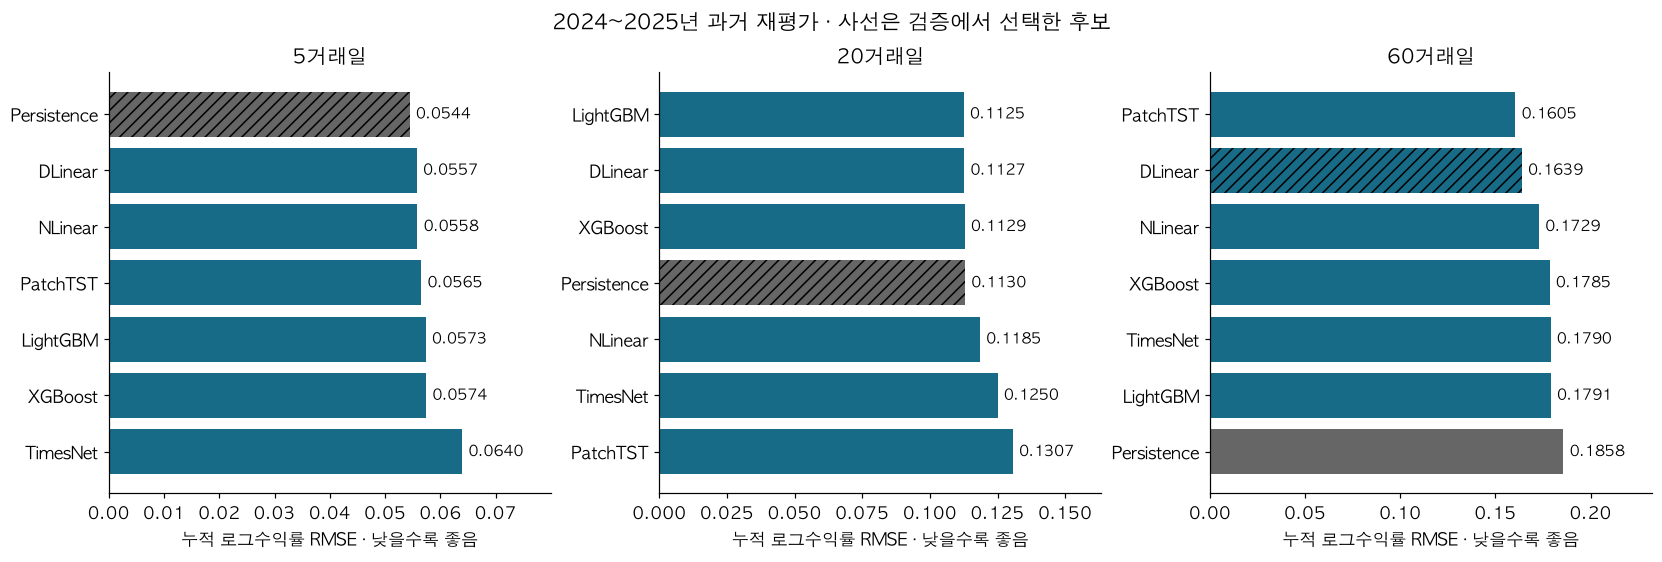

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), layout="constrained")
for ax, h in zip(axes, HORIZONS):
    table = evaluation_scores.loc[evaluation_scores["지평"].eq(h)].sort_values("RMSE", ascending=False)
    colors = ["#666666" if m=="Persistence" else "#176B87" for m in table["모델"]]
    bars = ax.barh(table["모델"], table["RMSE"], color=colors)
    for bar, is_chosen in zip(bars, table["검증 선택"].eq("선택")):
        if is_chosen:
            bar.set_hatch("///")
    ax.bar_label(bars, fmt="%.4f", padding=4, fontsize=10)
    ax.set_xlim(0, table["RMSE"].max()*1.25)
    ax.set_title(f"{h}거래일")
    ax.set_xlabel("누적 로그수익률 RMSE · 낮을수록 좋음")
fig.suptitle("2024~2025년 과거 재평가 · 사선은 검증에서 선택한 후보", fontsize=14)
plt.show()

**5거래일 · 연도별 Persistence 대비 RMSE 개선율 (%)**

| 모델        |   2024 |   2025 |
|:------------|-------:|-------:|
| DLinear     |  -2.69 |  -2.17 |
| LightGBM    |  -2.42 |  -7.27 |
| NLinear     |  -2.43 |  -2.68 |
| PatchTST    |   0.97 |  -7.01 |
| Persistence |   0.00 |   0.00 |
| TimesNet    | -12.42 | -20.78 |
| XGBoost     |  -2.36 |  -7.57 |

**20거래일 · 연도별 Persistence 대비 RMSE 개선율 (%)**

| 모델        |   2024 |   2025 |
|:------------|-------:|-------:|
| DLinear     |  -0.12 |   0.54 |
| LightGBM    |   6.23 |  -3.29 |
| NLinear     |  -3.63 |  -5.71 |
| PatchTST    |  -1.34 | -24.35 |
| Persistence |   0.00 |   0.00 |
| TimesNet    |  13.95 | -24.54 |
| XGBoost     |   5.55 |  -3.38 |

**60거래일 · 연도별 Persistence 대비 RMSE 개선율 (%)**

| 모델        |   2024 |   2025 |
|:------------|-------:|-------:|
| DLinear     |   1.35 |  30.49 |
| LightGBM    |  -0.37 |   9.91 |
| NLinear     |   3.49 |  12.35 |
| PatchTST    |  15.36 |  11.00 |
| Persistence |   0.00 |   0.00 |
| TimesNet    |  33.99 | -29.40 |
| XGBoost     |   2.11 |   6.73 |

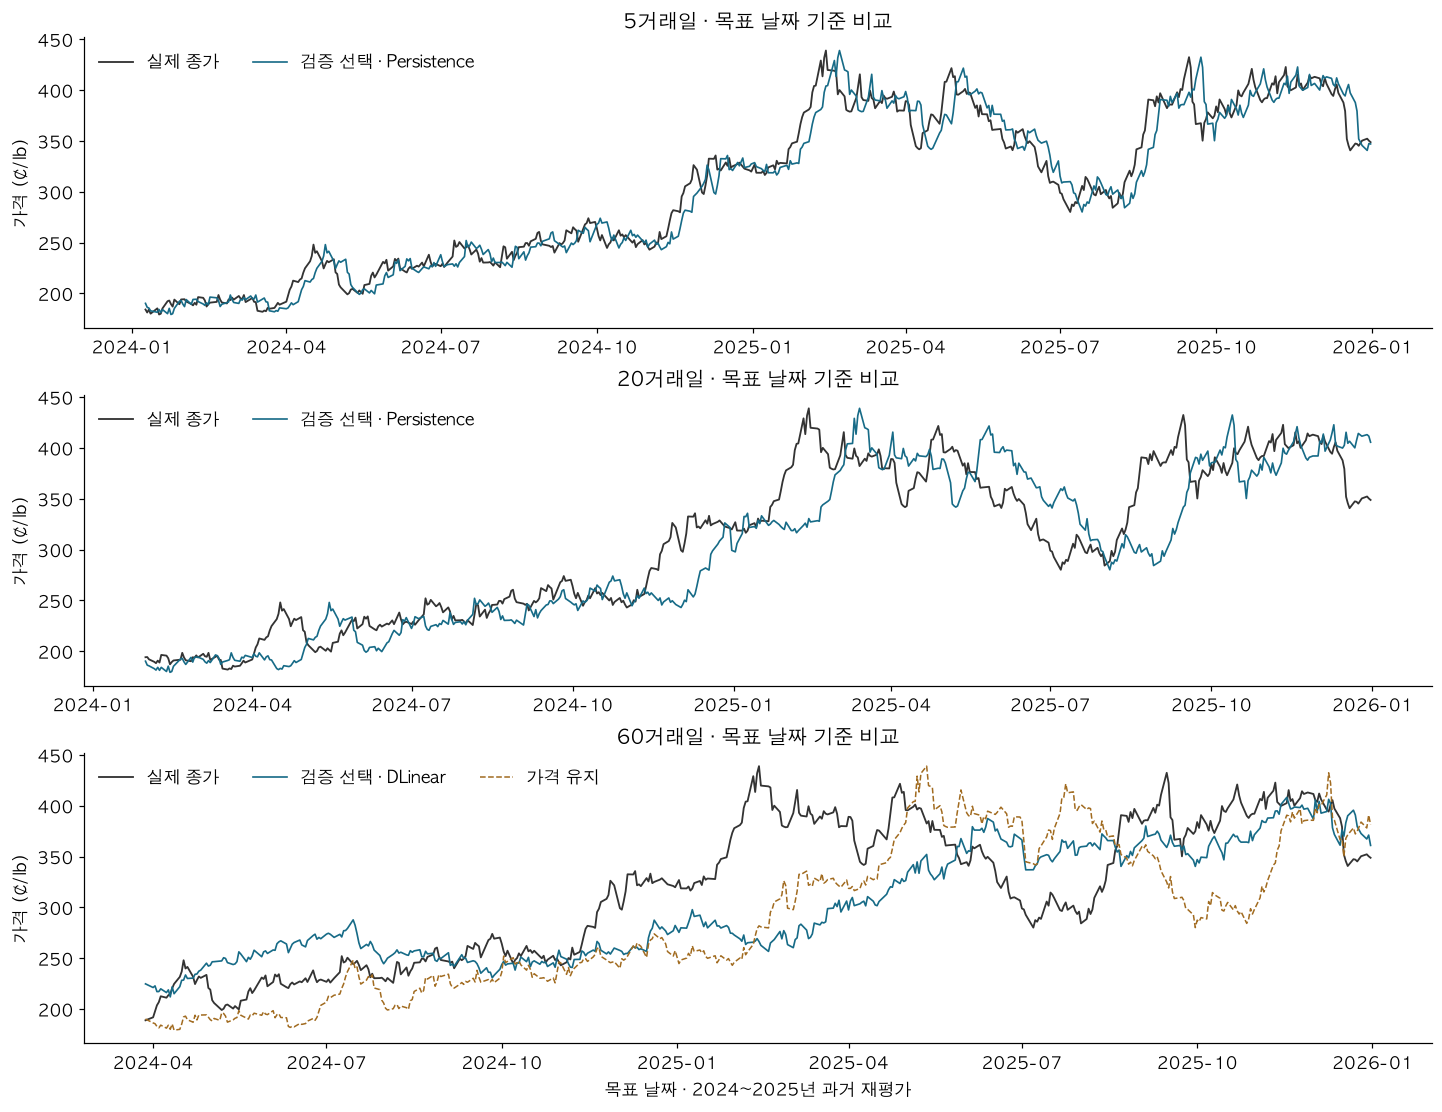

In [9]:
period_rows = []
for (h, name, year), frame in evaluation_predictions.groupby(
        ["horizon", "model", evaluation_predictions.origin_date.dt.year]):
    period_rows.append({"지평": h, "모델": name, "기준일 연도": year, **score_predictions(frame)})
period_scores = pd.DataFrame(period_rows)
for h in HORIZONS:
    display(Markdown(f"**{h}거래일 · 연도별 Persistence 대비 RMSE 개선율 (%)**"))
    show_table(period_scores.loc[period_scores["지평"].eq(h)].pivot(
        index="모델", columns="기준일 연도", values="Persistence 대비 개선 (%)").reset_index(), 2)

fig, axes = plt.subplots(3, 1, figsize=(13, 10), layout="constrained")
for ax, h in zip(axes, HORIZONS):
    name = chosen_model[h]
    frame = evaluation_predictions.loc[(evaluation_predictions.horizon==h) & (evaluation_predictions.model==name)].sort_values("target_date")
    ax.plot(frame.target_date, frame.current_price*np.exp(frame.actual_return), color="#333333", label="실제 종가", linewidth=1.2)
    ax.plot(frame.target_date, frame.current_price*np.exp(frame.predicted_return), color="#176B87", label=f"검증 선택 · {name}", linewidth=1.1)
    if name != "Persistence":
        ax.plot(frame.target_date, frame.current_price, color="#A16B20", linestyle="--", label="가격 유지", linewidth=1)
    ax.set_title(f"{h}거래일 · 목표 날짜 기준 비교")
    ax.set_ylabel("가격 (¢/lb)")
    ax.legend(loc="upper left", ncol=3, frameon=False)
axes[-1].set_xlabel("목표 날짜 · 2024~2025년 과거 재평가")
plt.show()

### 중첩 target의 민감도

60일 누적수익률은 인접 표본끼리 같은 가격 구간을 공유한다. 아래는 각 지평에서 origin 간격을 h 이상 띄운 시작점 세 가지의 결과다. **시작점별 표본은 서로 독립인 새 데이터가 아니며 합쳐 표본 수를 늘리지 않는다.** 작은 차이의 통계적 유의성이나 안정적 우월성은 주장하지 않는다.

In [10]:
sensitivity_rows = []
for (h, name), frame in evaluation_predictions.groupby(["horizon", "model"]):
    indices = SESSIONS.get_indexer(frame.origin_date)
    for offset in sorted({0, h//3, 2*h//3}):
        keep = (indices-indices.min()-offset) % h == 0
        part = frame.loc[keep]
        assert np.all(np.diff(indices[keep]) >= h)
        if len(part):
            sensitivity_rows.append({"지평": h, "모델": name, "시작 offset": offset, **score_predictions(part)})
sensitivity_scores = pd.DataFrame(sensitivity_rows)
summary = sensitivity_scores.groupby(["지평", "모델"], as_index=False).agg(
    최소_표본=("표본", "min"), 개선율_최소=("Persistence 대비 개선 (%)", "min"),
    개선율_최대=("Persistence 대비 개선 (%)", "max"))
show_table(summary, 2)
show_table(pd.DataFrame(timing_rows).groupby(["구간", "모델"], as_index=False)["초"].max().rename(columns={"초": "지평별 최대 실행 초"}), 1)
print("신경망 checkpoint 시간은 누적 시간이며 서로 합산하지 않습니다.")

|   지평 | 모델        |   최소_표본 |   개선율_최소 |   개선율_최대 |
|-------:|:------------|------------:|--------------:|--------------:|
|      5 | DLinear     |          99 |         -3.97 |         -0.80 |
|      5 | LightGBM    |          99 |         -7.21 |         -4.06 |
|      5 | NLinear     |          99 |         -4.13 |         -2.10 |
|      5 | PatchTST    |          99 |         -5.07 |         -3.29 |
|      5 | Persistence |          99 |          0.00 |          0.00 |
|      5 | TimesNet    |          99 |        -22.16 |        -14.35 |
|      5 | XGBoost     |          99 |         -7.32 |         -3.50 |
|     20 | DLinear     |          24 |         -4.37 |          1.69 |
|     20 | LightGBM    |          24 |         -5.75 |          8.26 |
|     20 | NLinear     |          24 |        -12.68 |         -3.52 |
|     20 | PatchTST    |          24 |        -21.84 |        -10.38 |
|     20 | Persistence |          24 |          0.00 |          0.00 |
|     20 | TimesNet    |          24 |        -36.59 |          8.84 |
|     20 | XGBoost     |          24 |         -3.60 |          6.31 |
|     60 | DLinear     |           7 |        -26.01 |         32.94 |
|     60 | LightGBM    |           7 |          2.35 |          5.48 |
|     60 | NLinear     |           7 |        -17.94 |         19.25 |
|     60 | PatchTST    |           7 |          2.36 |         25.46 |
|     60 | Persistence |           7 |          0.00 |          0.00 |
|     60 | TimesNet    |           7 |        -22.10 |         17.51 |
|     60 | XGBoost     |           7 |          0.74 |          5.52 |

| 구간        | 모델     |   지평별 최대 실행 초 |
|:------------|:---------|----------------------:|
| 2022        | DLinear  |                   1.1 |
| 2022        | LightGBM |                   7.3 |
| 2022        | NLinear  |                   0.4 |
| 2022        | PatchTST |                  20.0 |
| 2022        | TimesNet |                  15.6 |
| 2022        | XGBoost  |                  19.3 |
| 2023        | DLinear  |                   1.1 |
| 2023        | LightGBM |                   8.0 |
| 2023        | NLinear  |                   0.4 |
| 2023        | PatchTST |                  24.0 |
| 2023        | TimesNet |                  18.2 |
| 2023        | XGBoost  |                  20.3 |
| 과거 재평가 | DLinear  |                   0.5 |
| 과거 재평가 | LightGBM |                   3.3 |
| 과거 재평가 | NLinear  |                   0.2 |
| 과거 재평가 | PatchTST |                   9.3 |
| 과거 재평가 | TimesNet |                   7.3 |
| 과거 재평가 | XGBoost  |                   7.2 |

신경망 checkpoint 시간은 누적 시간이며 서로 합산하지 않습니다.


## 8. 결과 검증·저장과 해석

검증 설정별 예측, 재평가 개별 예측, 지표를 새 run 디렉터리에 저장한다. 데이터 파일만 `data/`에 넣으며 기존 결과를 덮어쓰지 않는다. 같은 origin·target·horizon의 개별 수익률 예측은 후속 단순평균 앙상블에 사용할 수 있다. 이번에는 평균 예측을 만들지 않는다.

In [11]:
for frame in (validation_predictions, evaluation_predictions):
    key = ["fold", "horizon", "model", "setting", "origin_date"]
    assert not frame.duplicated(key).any()
    assert (frame.train_cutoff < frame.origin_date).all()
    assert (frame.origin_date < frame.target_date).all()
    assert np.isfinite(frame[["actual_return", "predicted_return", "current_price"]]).all().all()
    for (fold, h), group in frame.groupby(["fold", "horizon"]):
        reference = group.loc[group.model.eq("Persistence")].sort_values("origin_date")
        for _, candidate in group.groupby(["model", "setting"]):
            candidate = candidate.sort_values("origin_date")
            assert candidate.origin_date.tolist() == reference.origin_date.tolist()
            assert candidate.target_date.tolist() == reference.target_date.tolist()
            np.testing.assert_allclose(candidate.actual_return, reference.actual_return)
assert len(selected) == len(HORIZONS)*(len(MODELS)+1)
assert len(evaluation_scores) == len(selected)
# 예측 행으로부터 계산한 점수를 결과표와 다시 대조한다.
for row in evaluation_scores.to_dict("records"):
    frame = evaluation_predictions.loc[(evaluation_predictions.horizon==row["지평"]) & (evaluation_predictions.model==row["모델"])]
    np.testing.assert_allclose(score_predictions(frame)["RMSE"], row["RMSE"])
def save_results(output, predictions, scores, yearly, nonoverlap):
    """완료된 결과만 공개하고, 동일 결과의 저장 셀 재실행은 허용한다."""
    output = Path(output)
    output.parent.mkdir(parents=True, exist_ok=True)
    with tempfile.TemporaryDirectory(prefix=f".{output.name}-", dir=output.parent) as temporary:
        stage = Path(temporary)
        predictions.to_parquet(stage / "individual_predictions.parquet", index=False)
        scores.to_csv(stage / "metrics.csv", index=False)
        yearly.to_csv(stage / "yearly_metrics.csv", index=False)
        nonoverlap.to_csv(stage / "nonoverlap_metrics.csv", index=False)
        pd.testing.assert_frame_equal(pd.read_parquet(stage / "individual_predictions.parquet"), predictions)
        if output.exists():
            if not output.is_dir() or {f.name for f in output.iterdir()} != {f.name for f in stage.iterdir()}:
                raise FileExistsError(f"기존 결과 구조가 다릅니다: {output}")
            for path in stage.iterdir():
                if path.suffix == ".parquet":
                    try:
                        pd.testing.assert_frame_equal(pd.read_parquet(output / path.name), predictions, check_exact=True)
                    except AssertionError as error:
                        raise FileExistsError(f"기존 예측이 달라 보존합니다: {output / path.name}") from error
                elif path.read_bytes() != (output / path.name).read_bytes():
                    raise FileExistsError(f"기존 결과가 달라 보존합니다: {output / path.name}")
        else:
            stage.rename(output)

# 저장 실패·재시도·충돌 시 기존 파일 보존을 작은 실제 파일로 확인한다.
from unittest.mock import patch
with tempfile.TemporaryDirectory(prefix="coffee-save-check-") as temporary:
    base = Path(temporary)
    sample = pd.DataFrame({"value": [1.0]})
    save_results(base / "same", sample, sample, sample, sample)
    save_results(base / "same", sample, sample, sample, sample)
    previous = (base / "same" / "metrics.csv").read_bytes()
    try:
        save_results(base / "same", sample, sample*2, sample, sample)
    except FileExistsError:
        assert (base / "same" / "metrics.csv").read_bytes() == previous
    else:
        raise AssertionError("충돌한 결과를 덮어쓰면 안 됩니다.")
    with patch.object(pd.DataFrame, "to_csv", side_effect=OSError("simulated write failure")):
        try:
            save_results(base / "retry", sample, sample, sample, sample)
        except OSError:
            assert not (base / "retry").exists()
        else:
            raise AssertionError("저장 실패 검사가 실행되지 않았습니다.")
    assert not list(base.glob(".retry-*"))
    save_results(base / "retry", sample, sample, sample, sample)
print("저장 재실행·실패 복구·충돌 보존 검사 통과")

all_predictions = pd.concat([validation_predictions, evaluation_predictions], ignore_index=True)
all_scores = pd.concat([validation_scores.assign(구간="검증"), evaluation_scores.assign(구간="과거 재평가")], ignore_index=True)
save_results(OUTPUT, all_predictions, all_scores, period_scores, sensitivity_scores)
print("검증 통과: 6개 모델×3개 지평, 공통 날짜·정답·예측 및 지표 대조")
print("데이터 결과 저장:", OUTPUT.relative_to(ROOT))
summary_rows = []
for h in HORIZONS:
    table = evaluation_scores.loc[evaluation_scores["지평"].eq(h)]
    chosen = table.loc[table["모델"].eq(chosen_model[h])].iloc[0]
    best_single = table.loc[~table["모델"].eq("Persistence")].sort_values("RMSE").iloc[0]
    summary_rows.append({"지평": h, "검증 선택": chosen_model[h], "선택 후보 재평가 RMSE": chosen["RMSE"],
                         "선택 후보 개선 (%)": chosen["Persistence 대비 개선 (%)"],
                         "사후 단일 모델 최저": best_single["모델"], "사후 최저 RMSE": best_single["RMSE"]})
show_table(pd.DataFrame(summary_rows))
display(Markdown("**해석:** 검증 선택과 사후 최저 모델을 구분한다. 과거 재평가·단일 seed·제한된 튜닝 결과로 서빙 모델을 교체하거나 안정적 개선을 확정하지 않는다. 다음 단계에서 앙상블을 시험한다면 시간순 검증 예측만으로 구성원을 선택한 뒤 단순평균을 평가한다."))

저장 재실행·실패 복구·충돌 보존 검사 통과
검증 통과: 6개 모델×3개 지평, 공통 날짜·정답·예측 및 지표 대조
데이터 결과 저장: data/processed/single_model_comparison/20260926T115735770501Z


|   지평 | 검증 선택   |   선택 후보 재평가 RMSE |   선택 후보 개선 (%) | 사후 단일 모델 최저   |   사후 최저 RMSE |
|-------:|:------------|------------------------:|---------------------:|:----------------------|-----------------:|
|      5 | Persistence |                 0.05444 |              0.00000 | DLinear               |          0.05574 |
|     20 | Persistence |                 0.11300 |              0.00000 | LightGBM              |          0.11251 |
|     60 | DLinear     |                 0.16388 |             11.78141 | PatchTST              |          0.16050 |

**해석:** 검증 선택과 사후 최저 모델을 구분한다. 과거 재평가·단일 seed·제한된 튜닝 결과로 서빙 모델을 교체하거나 안정적 개선을 확정하지 않는다. 다음 단계에서 앙상블을 시험한다면 시간순 검증 예측만으로 구성원을 선택한 뒤 단순평균을 평가한다.